In [ ]:
import warnings 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx 
from networkx.drawing.nx_agraph import graphviz_layout

from glob import glob 

warnings.filterwarnings('ignore')
%matplotlib inline
%load_ext autoreload
%autoreload 2

pd.options.display.float_format = "{:,.2f}".format
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

INDIR_DPCLUST = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/dpclust_ccf'
INDIR_CONIPHER = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/conipher_trees'
INFILE_MUTATIONS = '/home/grace/work/PPCG_DifferentialGenesetMutation/outputs/angel_mutations_all_donors/variant_processing/mutations.filtered.tsv'
INFILE_SHEET = '/home/grace/work/PPCG_DifferentialGenesetMutation/samplesheet.angel.alldonors.tsv'

# PPCG0213a has no mutations. 
# Some PPCG donors are multisample primary. 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
muts = pd.read_csv(INFILE_MUTATIONS, sep='\t', header=0)
sheet = pd.read_csv(INFILE_SHEET, sep='\t', header=0)
valid = set(sheet['sample'].unique())
muts = muts[muts['sample'].isin(valid)].copy()

donor2cohort = sheet.drop_duplicates('donor').set_index('donor')['cohort'].to_dict()
sample2tissue = sheet.drop_duplicates('sample').set_index('sample')['tissue'].to_dict()
muts['cohort'] = muts['donor'].map(donor2cohort)
muts['tissue'] = muts['sample'].map(sample2tissue)

muts.head()

,sample,donor,coords,ref,alt,vclass,vtype,annotation,est_ccf,gene,cohort,tissue
0,PPCG0322a,PPCG0322,3:132062590-21:42839615,.,.,SV,TRA,gene_fusion,NaN,ACP3,PPCG,Primary
1,PPCG0322a,PPCG0322,3:132062590-21:42839615,.,.,SV,TRA,gene_fusion,NaN,TMPRSS2,PPCG,Primary
2,PPCG0322a,PPCG0322,4:153179188-5:71525815,.,.,SV,TRA,transcript_ablation,NaN,MRPS27,PPCG,Primary
3,PPCG0322a,PPCG0322,9:9618517-9:9619627,.,.,SV,INV,bidirectional_gene_fusion,NaN,PTPRD,PPCG,Primary
4,PPCG0322a,PPCG0322,9:9474532-9:9619633,.,.,SV,INV,bidirectional_gene_fusion,NaN,PTPRD,PPCG,Primary


In [ ]:
# # donors with dpclust 
# donors_dpc = set([x.split('/')[-1][:8] for x in glob(f"{INDIR_DPCLUST}/*_Cluster_CCFs.csv")])

# # donors with conipher trees
# donors_con = set([x.split('/')[-2][:8] for x in glob(f"{INDIR_CONIPHER}/*/allTrees.txt")])

# pdonors = set(muts[muts['tissue']=='Primary']['donor'].unique())
# mdonors = set(muts[muts['tissue']=='Metastasis']['donor'].unique())
# rdonors = set(muts[muts['tissue']=='Recurrence']['donor'].unique())
# cmapper = sheet.drop_duplicates('donor').set_index('donor')['cohort'].to_dict()
# counts = muts.groupby('donor')['sample'].nunique().to_frame().reset_index()
# counts['Primary'] = counts['donor'].apply(lambda x: x in pdonors)
# counts['Metastasis'] = counts['donor'].apply(lambda x: x in mdonors)
# counts['Recurrence'] = counts['donor'].apply(lambda x: x in rdonors)
# counts['DPClust'] = counts['donor'].apply(lambda x: x in donors_dpc)
# counts['CONIPHER'] = counts['donor'].apply(lambda x: x in donors_con)
# counts['cohort'] = counts['donor'].map(cmapper)

# combi_no_dpc = set(counts[(counts['cohort']=='COMBI') & (counts['DPClust']==False)]['donor'].unique())
# combi_no_con = set(counts[(counts['cohort']=='COMBI') & (counts['CONIPHER']==False)]['donor'].unique())
# missing_tree = set(counts[(counts['DPClust']==True) & (counts['CONIPHER']==False)]['donor'].unique())
# missing_pri = set(counts[(counts['CONIPHER']==True) & (counts['Primary']==False)]['donor'].unique())
# missing_met = set(counts[(counts['CONIPHER']==True) & ((counts['Metastasis']==False) & (counts['Recurrence']==False))]['donor'].unique())
# ppcg_multi = set(counts[(counts['cohort']=='PPCG') & (counts['sample']>=2)]['donor'].unique())

# DPC_DONORS = set(counts[counts['DPClust']==True]['donor'].unique())
# TREE_DONORS = set(counts[counts['CONIPHER']==True]['donor'].unique())
# print(f"DPClust donors: {len(DPC_DONORS)}")
# print(f"CONIPHER donors: {len(TREE_DONORS)}")

# def pretty(donors: set[str], n=5) -> None:
#     lst = sorted(donors)
#     chunks = [lst[i:i + n] for i in range(0, len(lst), n)]
#     for chunk in chunks:
#         print('\t' + ','.join(chunk))

# print('\n1. (COMBI) Donors without DPClust\n')
# pretty(combi_no_dpc)

# # print('\n(COMBI) Donors without CONIPHER')
# # pretty(combi_no_con)

# print('\n2. (COMBI) DPClust but no CONIPHER tree\n')
# pretty(missing_tree)

# print('\n3. (COMBI) CONIPHER but no primary sample\n')
# pretty(missing_pri)

# # print('\n(COMBI) CONIPHER but no metastasis sample\n')
# # pretty(missing_met)

# print('\n4. (PPCG) Donors with multiple primary samples\n')
# pretty(ppcg_multi)

# counts[counts['donor'].isin(missing_tree)]

# # counts[counts['CONIPHER']==True].sort_values('Primary')


In [117]:
def load_dpclust_ccfs(filepath: str):
    df = pd.read_csv(filepath, sep=',', header=0)
    df['Cluster'] = df['Cluster'].astype(str)
    df['Cluster'] = df['Cluster'].apply(lambda x: x.replace('_', ''))
    df = df.set_index('Cluster')
    tmapper = df['Cluster_Type'].to_dict()
    df.columns = [x.replace('_DNA', '') for x in df.columns]
    df = df[[x for x in df.columns if x.startswith('PPCG')]].copy()
    return df, tmapper

def load_dpclust_asmts(filepath: str):
    donor = filepath.split('/')[-1][:8]
    df = pd.read_csv(filepath, sep=',', header=0)
    df['Cluster'] = df['Cluster'].astype(str)
    df['Cluster'] = df['Cluster'].apply(lambda x: x.replace('_', ''))
    df['donor'] = donor
    df['chr'] = df['chr'].astype(str)
    df['pos'] = df['pos'].astype(str)
    df['coords'] = df['chr'] + ':' + df['pos']
    df['ident'] = df['donor'] + '|SNV|' + df['coords']
    return df.set_index('ident')['Cluster'].to_dict()

def load_conipher_tree(filepath: str):
    T = nx.DiGraph()
    
    with open(filepath, 'r') as fp:
        top_line = fp.readline().strip()
        header_tree1 = fp.readline().strip()
        assert header_tree1 == '# tree 1'

        line = fp.readline().strip()
        while line and not line.startswith('#'):
            parent, child = line.split('\t')
            parent = parent.replace('_', '')
            child = child.replace('_', '')
            T.add_edge(parent, child)
            line = fp.readline().strip()

    return T

def draw_conipher_tree(T: nx.DiGraph) -> None:
    fig = plt.figure(figsize=(3, 3))
    pos = graphviz_layout(T, prog='dot')
    nx.draw_networkx_nodes(T, pos, node_color='white')
    nx.draw_networkx_labels(T, pos)
    nx.draw_networkx_edges(T, pos)
    plt.show()
    plt.close()

# filepath = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/dpclust_ccf/PPCG0087_SNV_CCF_Cluster_assignment.csv'
# asmts = load_dpclust_asmts(filepath)
# for k, v in list(asmts.items())[:5]:
#     print(k, v)

# PPCG0087|10:103904040|SNV|PPRC1
# PPCG0087|10:104592389|SNV|CYP17A1

In [ ]:
# NOTE: THIS MUST BE UPDATED TO BE SENSITIVE FOR THE VARIANT TYPE!!!
# eg some donors are missing a SV.vcf file for a particular sample.
# therefore matching to the DPClust ccfs no longer makes sense. 
# what to do: for these particular situations, remove DPClust ccf_t rows 
# corresponding to samples with missing files. should be able to keep the rest of the method the same. 

donor2ccfpath = {x.split('/')[-1][:8]: x for x in glob(f"{INDIR_DPCLUST}/*_Cluster_CCFs.csv")}
donor2asmtpath = {x.split('/')[-1][:8]: x for x in glob(f"{INDIR_DPCLUST}/*_SNV_CCF_Cluster_assignment.csv")}
donor2treepath = {x.split('/')[-2][:8]: x for x in glob(f"{INDIR_CONIPHER}/*/allTrees.txt")}

# 'annot' is the summary table
annot = muts.copy()

# drop duplicates. 
# sorting ensures higher ccf replicates are kept. 
annot = annot.sort_values('est_ccf', ascending=False)
# SNV/INDEL: exact variant duplicates. 
shard1 = annot[annot['vclass'].isin(['SNV', 'INDEL'])].copy()
shard1 = shard1.drop_duplicates(subset=['sample', 'vclass', 'coords'])
# SV/CNA: gene level duplicates (ie if PPCG0001a has 2 SVs in the ERG gene)
shard2 = annot[annot['vclass'].isin(['SV', 'CNA'])].copy()
shard2 = shard2.drop_duplicates(subset=['sample', 'vclass', 'gene'])
# recombine 
annot = pd.concat([shard1, shard2], ignore_index=True)

# derive identifier 'ident' for each variant
mask = annot['vclass'].isin(['SV', 'CNA'])
annot.loc[mask, 'ident'] = annot['donor'] + '|' + annot['vclass'] + '|' + annot['gene']
annot.loc[~mask, 'ident'] = annot['donor'] + '|' + annot['vclass'] + '|' + annot['coords']

# mark SV est_ccf as 1.00 so that the method does not need alteration. 
# eventually gets reset to pd.NA.
mask = annot['vclass']=='SV'
annot.loc[mask, 'est_ccf'] = 1.00
assert annot['est_ccf'].isna().sum() == 0 

# annotate clonality
annot['clonality'] = annot['est_ccf'].apply(lambda x: 'subclonal' if x<=0.9 else 'clonal')

# formatting
annot = annot[['ident', 'cohort', 'donor', 'sample', 'tissue', 'est_ccf', 'vclass']].copy()
annot = annot.sort_values('ident')
annot.head()

var2clone = {}
var2lineage = {}

all_donors = sorted(donor2treepath.keys())[:5]
annot = annot[annot['donor'].isin(all_donors)].copy()
for donor in all_donors:
    print(donor)
    
    T = load_conipher_tree(donor2treepath[donor])
    asmts = load_dpclust_asmts(donor2asmtpath[donor])
    ccfs, tmapper = load_dpclust_ccfs(donor2ccfpath[donor])
    
    complete = set(asmts.keys())
    for var, clone in asmts.items():
        var2clone[var] = clone
        var2lineage[var] = tmapper[clone]
    
    ccfs_t = ccfs.T
    all_clones = ccfs.index.to_list()

    df = annot[annot['donor']==donor].copy()
    df = df[~df['ident'].isin(complete)].copy()
    df = df.set_index('sample')

    chunks = {var: dfslice for var, dfslice in df.groupby('ident')}
    for var, dfslice in chunks.items():

        scores = []
        ccfs_temp = ccfs_t.copy()
        ccfs_temp['observed'] = dfslice['est_ccf'].to_dict()
        ccfs_temp['observed'] = ccfs_temp['observed'].fillna(0.0)

        for clone in all_clones:
            # sum absolute difference between expected and observed ccf across all samples
            diff = (ccfs_temp[clone]-ccfs_temp['observed']).abs().sum()
            # extra penalty for situations involving ccf=0.0  
            # - clone not in sample, but variant is detected (-1 score because this feels bad)
            # - clone in sample, but variant not detected (-0.5 score because somewhat explainable)
            penalty1 = ((ccfs_temp[clone]==0.0) & (ccfs_temp['observed']>0.0)).sum() * 1.0
            penalty2 = ((ccfs_temp[clone]>0.0) & (ccfs_temp['observed']==0.0)).sum() * 0.5
            score = diff + penalty1 + penalty2
            # print(f"clone={clone}, diff={round(diff, 2)}, penalty1={penalty1}, penalty2={penalty2}, score={round(score, 2)}")
            scores.append((clone, float(round(score, 2))))
            # NOTE: SVs get set an est_ccf of 1.00 so this method does not need alteration. Still works but less sensitive. 
        
        # pick clone and retrieve clone type label as lineage.
        scores = sorted(scores, key=lambda x: x[1])
        clone = scores[0][0]
        lineage = tmapper[clone]

        # update maps.
        var2clone[var] = clone
        var2lineage[var] = lineage

annot['tree_clone'] = annot['ident'].map(var2clone)
annot['lineage'] = annot['ident'].map(var2lineage)

# reset SV est_ccf to NA
mask = annot['vclass']=='SV'
annot.loc[mask, 'est_ccf'] = pd.NA
assert annot['clone'].isna().sum() == 0 
assert annot['lineage'].isna().sum() == 0 

annot.head()


,ident,cohort,donor,sample,tissue,est_ccf,vclass,clone,lineage
135277,PPCG0086|CNA|BMI1,COMBI,PPCG0086,PPCG0086d,Metastasis,1.000,CNA,52,Leaf
135262,PPCG0086|CNA|COMMD3,COMBI,PPCG0086,PPCG0086d,Metastasis,1.000,CNA,52,Leaf
180826,PPCG0086|CNA|DUSP26,COMBI,PPCG0086,PPCG0086d,Metastasis,0.230,CNA,101,Leaf
180809,PPCG0086|CNA|FUT10,COMBI,PPCG0086,PPCG0086d,Metastasis,0.230,CNA,101,Leaf
180828,PPCG0086|CNA|MAK16,COMBI,PPCG0086,PPCG0086d,Metastasis,0.230,CNA,101,Leaf



PPCG0086


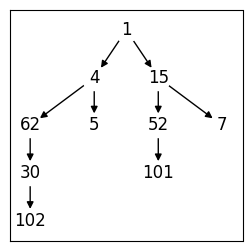

         PPCG0086a  PPCG0086c  PPCG0086d  PPCG0086e
Cluster                                            
1             0.99       1.01       1.01       1.00
4             0.97       0.00       0.00       1.01
5             0.96       0.00       0.00       0.00
7             0.00       0.33       0.00       0.00
101           0.00       0.00       0.28       0.00
102           0.00       0.00       0.00       0.11
15            0.00       0.97       1.02       0.00
30            0.00       0.00       0.00       0.35
52            0.00       0.00       0.95       0.00
62            0.00       0.00       0.00       0.85

vclass
SV       1270
SNV       640
INDEL      77
CNA        10
Name: count, dtype: int64

lineage  Branch  Leaf  Seed  Trunk
vclass                            
CNA        0.00  1.00  0.00   0.00
INDEL      0.05  0.17  0.16   0.62
SNV        0.13  0.26  0.03   0.58
SV         0.17  0.15  0.07   0.61

clone     1  101  102   15   30    4    5   52   62    7
vclass           

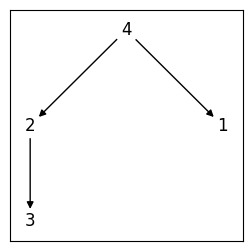

         PPCG0087a  PPCG0087c
Cluster                      
1             0.00       0.53
2             0.82       0.30
3             0.82       0.00
4             1.00       1.00

vclass
SV       276
SNV      259
INDEL     15
Name: count, dtype: int64

lineage  Leaf  Trunk
vclass              
INDEL    0.33   0.67
SNV      0.24   0.76
SV       0.39   0.61

clone     1    3    4
vclass               
INDEL  0.07 0.27 0.67
SNV    0.05 0.19 0.76
SV     0.21 0.18 0.61

PPCG0088


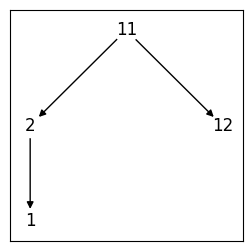

         PPCG0088a  PPCG0088c  PPCG0088d
Cluster                                 
1             0.00       0.00       0.45
2             0.00       0.00       0.97
11            1.01       1.02       1.00
12            1.04       0.84       0.00

vclass
SNV      274
SV       198
INDEL     32
CNA        3
Name: count, dtype: int64

lineage  Branch  Leaf  Trunk
vclass                      
CNA        0.00  1.00   0.00
INDEL      0.25  0.12   0.62
SNV        0.14  0.11   0.75
SV         0.12  0.29   0.59

clone     1   11   12    2
vclass                    
CNA    1.00 0.00 0.00 0.00
INDEL  0.00 0.62 0.25 0.12
SNV    0.04 0.75 0.14 0.07
SV     0.00 0.59 0.12 0.29

PPCG0089


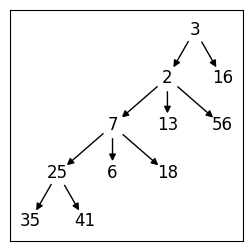

         PPCG0089a  PPCG0089c  PPCG0089d  PPCG0089e  PPCG0089f  PPCG0089g  PPCG0089h  PPCG0089i  PPCG0089j
Cluster                                                                                                   
2             1.03       0.99       0.93       0.91       0.00       0.96       0.98       0.97       1.02
3             1.01       0.98       1.00       0.97       1.03       1.00       1.00       1.01       1.03
6             0.83       0.00       0.00       0.00       0.00       0.00       0.00       0.00       0.00
7             1.07       0.97       0.98       0.98       0.00       0.86       1.00       0.00       0.00
13            0.00       0.00       0.00       0.00       0.00       0.00       0.00       0.86       0.00
16            0.00       0.00       0.00       0.00       1.01       0.00       0.00       0.00       0.00
18            0.00       0.00       1.00       0.00       0.00       0.00       0.00       0.00       0.00
25            0.00       0.96       0

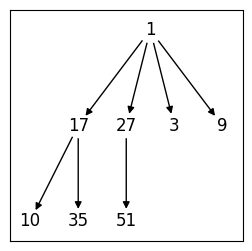

         PPCG0102a  PPCG0102c  PPCG0102d  PPCG0102e  PPCG0102f
Cluster                                                       
1             0.98       1.00       1.01       1.00       1.00
3             0.95       0.00       0.00       0.00       0.00
51            0.00       0.00       0.21       0.00       0.00
9             0.00       0.00       0.00       0.99       0.00
10            0.00       0.29       0.00       0.00       0.00
17            0.00       0.95       0.00       0.00       0.94
27            0.00       0.00       0.61       0.00       0.00
35            0.00       0.00       0.00       0.00       0.98

vclass
SV       2150
SNV      1213
CNA        70
INDEL      69
Name: count, dtype: int64

lineage  Branch  Leaf  Trunk
vclass                      
CNA        0.00  0.03   0.97
INDEL      0.10  0.13   0.77
SNV        0.02  0.10   0.88
SV         0.04  0.09   0.87

clone     1   10   17   27    3   35   51    9
vclass                                        
CNA    0.9

In [134]:
for donor in sorted(annot['donor'].unique()):
    T = load_conipher_tree(donor2treepath[donor])
    ccfs, tmapper = load_dpclust_ccfs(donor2ccfpath[donor])
    print()
    print(donor)
    draw_conipher_tree(T)
    print(ccfs)
    print()
    df = annot[annot['donor']==donor]
    df = df.sort_values('ident')
    print(df['vclass'].value_counts())
    print()
    print(df.groupby('vclass')['lineage'].value_counts(dropna=False, normalize=True).unstack().fillna(0.0).astype(float))
    print()
    print(df.groupby('vclass')['clone'].value_counts(dropna=False, normalize=True).unstack().fillna(0.0).astype(float))
    # for lineage in df['lineage'].unique():
    #     print(f"\n{lineage}")
    #     print(df[df['lineage']==lineage].head(10))

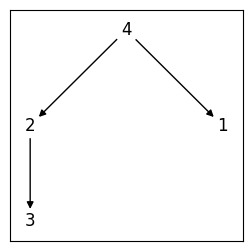

,PPCG0087a,PPCG0087c
Cluster,,
1,0.000,0.530
2,0.820,0.300
3,0.820,0.000
4,1.000,1.000


In [82]:
donor = 'PPCG0087'
T = load_conipher_tree(donor2treepath[donor])
ccfs, tmapper = load_dpclust_ccfs(donor2ccfpath[donor])
draw_conipher_tree(T)
ccfs

In [86]:
annot.groupby('vclass')['lineage'].value_counts().unstack().fillna(0).astype(int)

lineage,Leaf,Seed,Trunk
vclass,,,
INDEL,5,0,10
SNV,77,32,154
SV,108,0,168


In [ ]:
# counts = annot[annot['lineage']=='Leaf']['ident'].value_counts()
# print(counts.value_counts())
# targets = set(counts[counts>=2].index.to_list())
# # print(counts.value_counts())
# # print()
# # print(annot[annot['ident'].isin(targets)]['vclass'].value_counts())
# annot[annot['ident'].isin(targets)].head(10)

count
1    190
Name: count, dtype: int64


,ident,cohort,sample,tissue,est_ccf,vclass,clone,lineage
